# Session 6: Homework 3

**Author:** Your name goes here  
**Date:** 

In [ ]:
# We import the libraries to be used in this project

import pandas as pd                # pandas is used for manipulating & analysing data structures
import numpy as np                 # numpy is a comprehensive library with several mathematical functions
import matplotlib.pyplot as plt    # matplotlib.pyplot is a library used for creating data visualisations
import seaborn as sns              # seaborn: good for building visually appealing & statistically informative graphs
from scipy import stats     # Advanced statistical functions
from scipy.stats import ttest_ind
from scipy.stats import t  # For t-distribution (used in confidence intervals)
from statsmodels.stats.proportion import proportion_confint  # For calculating confidence intervals for proportions
import statsmodels.formula.api as smf  # For statistical models
import warnings                    # this is used to control how warnings are handled in our project
warnings.filterwarnings('ignore')

# Setting the styling for our plots
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'


# Youth Risk Behavior Surveillance

Data from the CDC YRBSS survey.

Every two years, the Centers for Disease Control and Prevention conduct the [Youth Risk Behavior Surveillance System (YRBSS)](https://www.cdc.gov/healthyyouth/data/yrbs/index.htm) survey, where it takes data from high schoolers (9th through 12th grade), to analyze health patterns. You will work with a selected group of variables from a random sample of observations during one of the years the YRBSS was conducted.


In [15]:
# Load the data (replace with actual path if needed)
yrbss = pd.read_csv('../data/yrbss.csv')
print(yrbss.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13583 entries, 0 to 13582
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       13506 non-null  float64
 1   gender                    13571 non-null  object 
 2   grade                     13504 non-null  object 
 3   hispanic                  13352 non-null  object 
 4   race                      10778 non-null  object 
 5   height                    12579 non-null  float64
 6   weight                    12579 non-null  float64
 7   helmet_12m                13272 non-null  object 
 8   text_while_driving_30d    12665 non-null  object 
 9   physically_active_7d      13310 non-null  float64
 10  hours_tv_per_school_day   13245 non-null  object 
 11  strength_training_7d      12407 non-null  float64
 12  school_night_hours_sleep  12335 non-null  object 
dtypes: float64(5), object(8)
memory usage: 1.3+ MB
None


## Exploratory Data Analysis
- Analyze the `weight` of participants in kilograms. quick summary stats with `describe()`
- How many missing weights?
- what does a quick histogram of weights look like?


In [ ]:
# Example: EDA on weight


## Physical Activity Variable
- Create a new variable `physical_3plus`, by looking whether the variable `physically_active_7d` is greater than 3.
- Calculate number and % of those who are and are not active for more than 3 days. 


In [ ]:
# Example: Create new variable




## 95% Confidence Interval for Proportion
- Calculate a 95 CI for those NOT active 3+ days. Do you get the same answer as the one provided  by proportion_confint() from statsmodels.stats.proportion??


In [16]:
# Example: 95% CI for proportion
from statsmodels.stats.proportion import proportion_confint
count = (yrbss['physical_3plus'] == 'no').sum()
nobs = len(yrbss)
ci_low, ci_upp = proportion_confint(count, 
                                    nobs, 
                                    alpha=0.05, 
                                    method='normal')

print(f'95% CI: {ci_low:.3f}, {ci_upp:.3f}')



KeyError: 'physical_3plus'

## Boxplot: physical_3plus vs. weight

Create a boxplot of weight (y-axis) by physical_3plus (x-axis) using seaborn. What do you observe?

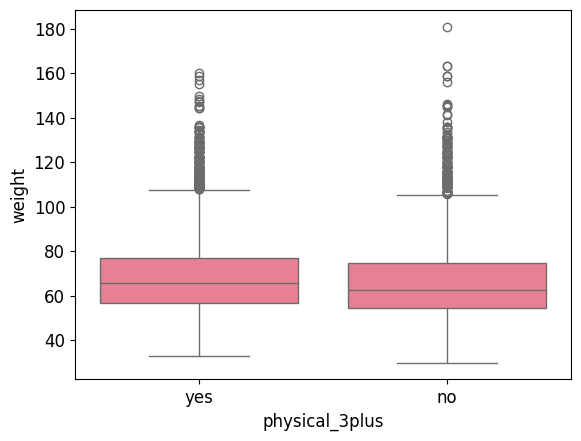

## Confidence Interval for Means

Looking at the variable `weight`, calculate a 95% confidence interval for the mean weight of participants for those who are physically active 3+ days a week and those who are not. Do you observe a difference in the mean weight between the two groups? You can adjust he code from the movies example

## Hypothesis Test: t-test

Is the difference in the mean weight between those who exercise 3+ days and those who dont, statistically significant? State what is your null and alternative hypothsis, and use a t-test to check.

You have to define the two groups and use the `ttest_ind()` function from scipy.stats. We also provide the regression code below, which you can use to check whether the two give us the same answer.

In [17]:
# --- Statsmodels t-test using a linear model (regression) ---
model = smf.ols('weight ~ C(physical_3plus)', data=yrbss).fit()

print(model.summary())







PatsyError: Error evaluating factor: NameError: name 'physical_3plus' is not defined
    weight ~ C(physical_3plus)
             ^^^^^^^^^^^^^^^^^

## IMDB ratings: Differences between directors
- From the movies dataset, get those movies directed by Spielberg and Burton
- Produce two confidence intervals for the average rating of these two directors
- Do the confidence intervals overlap?
- Run t-test 


In [18]:
movies = pd.read_csv('../data/movies.csv')
# # Filter for Spielberg and Burton


# # Calculate means, CIs, plot


## Omega Group plc- Pay Discrimination

This is a good exercise in building models and illustrates the link between confidence intervals, hypothesis testing, and regression. 
 
At the last board meeting of Omega Plc., the headquarters of a large multinational company, the issue was raised that women were being discriminated in the company, in the sense that the salaries were not the same for male and female executives. A quick analysis of a sample of 50 employees (of which 24 men and 26 women) revealed that the average salary for men was about ?8,400 higher than for women. This seemed like a considerable difference, so it was decided that a further analysis of the company salaries was warranted. 

You are asked to carry out the analysis. The objective is to find out whether there is indeed a significant difference between the salaries of men and women, and whether the difference is due to discrimination or whether it is based on another, possibly valid, determining factor.

The data frame `omega`  contains the salaries for the sample of 50 executives in the company. Can you conclude that there is a significant difference between the salaries of the male and female executives?

Note that you can perform different types of analyses, and check whether they all lead to the same conclusion (hint: they should!). You can use:

- Confidence intervals
- Hypothesis testing
- Correlation analysis
- Regression


In [19]:
omega = pd.read_csv('../data/omega.csv')
print(omega.groupby('gender')['salary'].describe().T.round(2))
# Calculate CI, t-test, regression


gender    female      male
count      26.00     24.00
mean    64542.84  73239.13
std      7567.26   7462.60
min     47032.57  54768.19
25%     60337.83  68331.31
50%     64618.21  74674.52
75%     70033.14  78568.11
max     78800.18  84576.11


First lets us draw a histogram and a boxplot to look at the distribution of salaries by gender. Rememebr that the line in the middle of each boxplot is the median, not the mean.

In [ ]:
# Code for boxplot + histogram by gender. adjust the code from credit_hypothesis_test.py

In [ ]:
from IPython import display
# The following table provides summary statistics. Add columns for the standard error (se), t-critical and lower/upper 95 CI endpoints

print(omega.groupby('gender')['salary'].describe().T.round(2))


#  Can you create the 95 and 99% confindence intervals 'by hand'?



# t-Critical values for 95% intervals for male (n=24) and female (n=26) salaries
result = t.ppf(0.975, 23)  # t-critical for male 
result = t.ppf(0.975, 23) # t-critical for female


# t-Critical values for 99% intervals for male (n=24) and female (n=26) salaries
result = t.ppf(0.995, 23)  # t-critical for male 
result = t.ppf(0.995, 23) # t-critical for female

# ADAPT the code from the movies example
# This is a complex chain of operations - let's break it down step by step:
salary_formula_ci = (
    omega                                    # Start with our filtered movies dataset
    .groupby('gender')['salary']              # Group by genre, focus on rating column
    .agg(['mean', 'std', 'count']) # Calculate statistics for each genre
    .rename(columns={                        # Rename columns to be clearer
        'mean': 'mean_rating', 
        'std': 'sd_rating'
    })
    .assign(                                 # Add new calculated columns
        # t_critical: the number we multiply by to get 95% confidence
        # It comes from the t-distribution (used when we don't know the population standard deviation)
        t_critical=lambda x: stats.t.ppf(0.975, x['count'] - 1),
        
        # Standard error: how much our sample mean might vary from the true mean
        # Smaller sample = higher error, More variable data = higher error
        se_rating=lambda x: x['sd_rating'] / np.sqrt(x['count']),
        
        # Margin of error: how far off our estimate might be
        margin_of_error=lambda x: x['t_critical'] * x['se_rating'],
        
        # The confidence interval bounds
        salary_low=lambda x: x['mean_rating'] - x['margin_of_error'],   # Lower bound
        salary_high=lambda x: x['mean_rating'] + x['margin_of_error']   # Upper bound
    )
    .sort_values(by='mean_rating', ascending=False)  # Sort by average rating (highest first)
    .round(2)                                        # Round to 2 decimal places
    .reset_index()                                   # Make genre a regular column again
)

salary_formula_ci

gender    female      male
count      26.00     24.00
mean    64542.84  73239.13
std      7567.26   7462.60
min     47032.57  54768.19
25%     60337.83  68331.31
50%     64618.21  74674.52
75%     70033.14  78568.11
max     78800.18  84576.11


,gender,mean_rating,sd_rating,count,t_critical,se_rating,margin_of_error,salary_low,salary_high
0,male,73239.0,7463.0,24,2.0,1523.0,3151.0,70088.0,76390.0
1,female,64543.0,7567.0,26,2.0,1484.0,3056.0,61486.0,67599.0


# Hypothesis Testing 

Run a a hypothesis testing, assuming as a null hypothesis that the mean difference in salaries is zero, or that, on average, men and women make the same amount of money.


In [37]:
# Series of every woman's salary
female_salary = omega[omega['gender'] == 'female']['salary']
# Series of every man's salary
male_salary = omega[omega['gender'] == 'male']['salary']


In [ ]:
# Run the independent t-test
# equal_var=False, makes this Welch's t-test instead of Student's. Student's t-test assumes both groups have the same variance; 
# Welch's does not, so it's safer when the two groups have different spread or different sample sizes. 
# It's the sensible default for comparing two independent groups.

t_stat, p_value = ttest_ind(female_salary, male_salary, equal_var=False)


print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")


t-statistic: -4.089090618793079, p-value: 0.00016508983562494724
t-statistic: -4.089
p-value: 0.000


# Regression Analysis 

we will fit a regression model to estimate effect of gender on salary. What is the estimated slope and its Standard Error? Are they similar to something you have seen before?


In [ ]:
# Fit linear model
model1 = smf.ols('salary ~ C(gender)', data=omega).fit()

# C(gender) tells statsmodels to treat gender as categorical. It picks one level as the baseline 
# (alphabetically, so Female) and creates a C(gender)[T.Male] term. That coefficient is the male mean minus the female mean — 
# the exact same difference your t-test measured, and its p-value will match the Welch test closely

print(model1.summary2())




                      Results: Ordinary least squares
Model:                  OLS                Adj. R-squared:       0.243     
Dependent Variable:     salary             AIC:                  1036.3489 
Date:                   2026-09-01 09:12   BIC:                  1040.1730 
No. Observations:       50                 Log-Likelihood:       -516.17   
Df Model:               1                  F-statistic:          16.70     
Df Residuals:           48                 Prob (F-statistic):   0.000165  
R-squared:              0.258              Scale:                5.6510e+07
---------------------------------------------------------------------------
                    Coef.     Std.Err.    t    P>|t|    [0.025     0.975]  
---------------------------------------------------------------------------
Intercept         64542.8362 1474.2627 43.7797 0.0000 61578.6323 67507.0400
C(gender)[T.male]  8696.2901 2127.9149  4.0868 0.0002  4417.8304 12974.7498
----------------------------------

TypeError: 'list' object is not callable

# Experience on Gender

At the board meeting, someone raised the issue that there was indeed a substantial difference between male and female salaries, but that this was attributable to other reasons such as differences in experience. A questionnaire send out to the 50 executives in the sample reveals that the average experience of the men is approximately 21 years, whereas the women only have about 7 years experience on average (see table below).

Can you do the analysis again, this time taking into account the experience of the executives? Start by plotting exeprience by gender, calcualte summary stats and 95 CIs, and include experience as an additional explanatory variable in your regression model. 



In [54]:
# Salary on Gender 

# Quick EDA/ visualisation


# Summary stats + CIs

# Regression Analysis
model2 = smf.ols('salary ~ gender', data=omega).fit()
print(model2.summary2())


                    Results: Ordinary least squares
Model:                 OLS               Adj. R-squared:      0.243     
Dependent Variable:    salary            AIC:                 1036.3489 
Date:                  2026-09-01 09:15  BIC:                 1040.1730 
No. Observations:      50                Log-Likelihood:      -516.17   
Df Model:              1                 F-statistic:         16.70     
Df Residuals:          48                Prob (F-statistic):  0.000165  
R-squared:             0.258             Scale:               5.6510e+07
------------------------------------------------------------------------
                 Coef.     Std.Err.    t    P>|t|    [0.025     0.975]  
------------------------------------------------------------------------
Intercept      64542.8362 1474.2627 43.7797 0.0000 61578.6323 67507.0400
gender[T.male]  8696.2901 2127.9149  4.0868 0.0002  4417.8304 12974.7498
------------------------------------------------------------------------

# Control for experience


If the gender coefficient shrinks a lot (or loses significance) once experience is in the model, then most of the raw gap was really an experience gap — men in the sample happened to have more years, and experience pays. The apparent gender effect was largely confounded.
If it stays roughly the same, the gap persists even among equally-experienced people, which is harder to explain away.

In [ ]:

# Now C(gender)[T.Male] answers a different, better question: the salary gap between men and women who have the same experience. 
# Read the two gender coefficients side by side:

model3 = smf.ols('salary ~ C(gender) + experience', data=omega).fit()
print(model3.summary2())

#  What is the meaning of the coefficient for experience, 559? Who makes this?


                      Results: Ordinary least squares
Model:                  OLS                Adj. R-squared:       0.632     
Dependent Variable:     salary             AIC:                  1001.1619 
Date:                   2026-09-01 09:18   BIC:                  1006.8980 
No. Observations:       50                 Log-Likelihood:       -497.58   
Df Model:               2                  F-statistic:          43.14     
Df Residuals:           47                 Prob (F-statistic):   2.30e-11  
R-squared:              0.647              Scale:                2.7432e+07
---------------------------------------------------------------------------
                    Coef.     Std.Err.    t    P>|t|    [0.025     0.975]  
---------------------------------------------------------------------------
Intercept         60414.1324 1176.2973 51.3596 0.0000 58047.7275 62780.5372
C(gender)[T.male]  1014.1056 1826.3901  0.5553 0.5814 -2660.1173  4688.3285
experience          559.0953   77.

# Model 4 — Does experience pay off differently by gender?

We will use an **interaction** model, 'salary ~ C(gender) * experience'

The * adds both main effects and their interaction. A significant C(gender)[T.Male]:experience term would mean the return to each year of experience differs between men and women (different slopes, not just different intercepts) — a subtler form of disparity than a flat gap.

How to interpret and report it

Give the numbers in dollars, not just stars: "unadjusted, men earn $X more on average; adjusting for experience, the gap falls to $Y." Two cautions worth stating explicitly:

This is observational data, so even the adjusted coefficient is an association, not proof of discrimination — experience could itself be shaped by other factors, and there may be confounders you haven't measured.
"Controlling for experience" can over-correct if experience is partly a consequence of the same unfairness (e.g., if one group was pushed out and accrued fewer years). Which variable is a fair control is a judgment call, not a purely statistical one.

In [ ]:
model4 = smf.ols('salary ~ C(gender) * experience', data=omega).fit()
print(model4.summary2())

                           Results: Ordinary least squares
Model:                     OLS                    Adj. R-squared:           0.648     
Dependent Variable:        salary                 AIC:                      999.9773  
Date:                      2026-09-01 09:21       BIC:                      1007.6254 
No. Observations:          50                     Log-Likelihood:           -495.99   
Df Model:                  3                      F-statistic:              31.01     
Df Residuals:              46                     Prob (F-statistic):       4.07e-11  
R-squared:                 0.669                  Scale:                    2.6299e+07
--------------------------------------------------------------------------------------
                               Coef.     Std.Err.    t    P>|t|    [0.025     0.975]  
--------------------------------------------------------------------------------------
Intercept                    59213.6343 1342.7300 44.0994 0.0000 56510.

This is the interaction model, salary ~ C(gender) * experience. Because gender is the dummy, Female, being alphabetically first, is the baseline, and every coefficient is read relative to women. The fitted equation is:

$$salary = 59213.63 + 4485.39·(male) + 721.66·(experience) − 270.06·(male × experience)$$

Here's what each term means.

- `Intercept`: 59213.63 (p ≈ 0.000)
The predicted salary for the baseline group at zero on every other variable: a woman with 0 years of experience earns about $59,214. It's just the starting point of the female line; the significance stars on an intercept rarely carry substantive meaning.

- `C(gender)[T.male]`: 4485.39 (p ≈ 0.101, CI −909 to 9879)
The male–female salary gap at experience = 0 — i.e. among brand-new hires, men are predicted to earn ~$4,485 more. Crucially, with an interaction in the model this term is not the overall gender gap; it's the gap specifically at the point where experience = 0. And it's not statistically significant — the confidence interval comfortably includes zero — so at entry level you can't distinguish it from no gap.

- `experience`: 721.66 (p ≈ 0.000)
The slope for the baseline group: each additional year of experience is worth about $722 more per year for women. Strongly significant — experience clearly pays.

- `C(gender)[T.male]:experience `: -270.06 (p ≈ 0.089, CI −583 to 42)
This is the heart of the interaction: the difference in the experience slope between men and women. Men's return to experience is 721.66 − 270.06 = $451.60 per year, versus $721.66 for women. The negative sign says each year of experience adds less to a man's salary than to a woman's. It's not significant (p ≈ 0.09, CI barely crosses zero), so treat it as suggestive rather than established.

Overall, the interaaction model here is not useful, as two terms are not significant. If they were significant, we could interpret it as follows:

> Men start ahead (+$4,485 at zero experience) but women gain $270 more per year, so the male advantage erodes with seniority. It disappears entirely at experience ≈ 4485.39 / 270.06 ≈ 16.6 years — beyond that, the model predicts women out-earn men. So this isn't a constant gender gap; it's an entry-level male advantage that flips over a career.

# Improving the Model

Again at the meeting, someone was looking at the results of the analysis of salary versus experience, and said that it was to be expected that an employee with more experience than another employee would have a higher salary. However, he argued that the difference in salary between two people with 2 and 4 years experience would be higher than the difference in salary between two people with 26 and 28 years experience!

> Can you find any indication that this is the case? If yes, how can you modify your analysis to take this into account?

# ✈️ NYC Flights 2023 

**Topics:** exploratory data analysis 
---

### The scenario

The `nycflights23` data records **every flight that departed the three New York
City airports (JFK, LGA, EWR) in 2023** — 435,352 flights in all — spread across
five related tables:

| table | one row is… | key columns |
|---|---|---|
| `flights`  | a scheduled flight | `carrier, origin, dest, dep_delay, arr_delay, distance, sched_dep_time, tailnum, time_hour` |
| `weather`  | one hour at one airport | `origin, time_hour, temp, wind_speed, precip, visib` |
| `planes`   | one aircraft | `tailnum, year` (manufactured), `manufacturer, model` |
| `airlines` | one carrier | `carrier, name` |
| `airports` | one airport | `faa, name, lat, lon` |

**Your role.** You are a data analyst advising an airline's network-operations
team. Throughout the assignment, keep one question in mind:

> **What actually drives arrival delays out of NYC — and what, if anything,
> should your stakeholder do about it?**


### Ground rules
- **Chained pandas.** Write your data manipulation as method chains
  (`df.merge(...).assign(...).query(...).groupby(...).agg(...)`), dplyr-style —
  not as a pile of intermediate variables. A worked example is given in Part 0.
- **seaborn** for every visualization.
- **Interpret everything.** A number or a plot with no sentence explaining what it
  *means for the stakeholder* earns no credit. See the rubric at the bottom.

---

In [ ]:

# Load NYC flights data

flights = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/nycflights23/flights.csv")
airlines = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/nycflights23/airlines.csv")
airports = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/nycflights23/airports.csv")
weather = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/nycflights23/weather.csv")
planes = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/nycflights23/planes.csv")


flights.head()

print("flights:", flights.shape)
flights.head(3)

for name, t in [("flights",flights),("weather",weather),("planes",planes),
                ("airports",airports),("airlines",airlines)]:
    print(f"{name:9s} {t.shape[0]:>7,d} rows x {t.shape[1]:>2d} cols")


flights: (435352, 19)
flights   435,352 rows x 19 cols
weather    26,207 rows x 15 cols
planes      4,840 rows x  9 cols
airports    1,255 rows x  8 cols
airlines       14 rows x  2 cols


###  Build one analysis frame  *(chained joins)*

We give you the **first** join (weather) as a template for the chained style.
**Your task:** extend the chain to also attach

1. each plane's manufacture year from `planes` (rename it `plane_year` so it does
   not collide with the flight `year`), and
2. the carrier's full `name` from `airlines`.

Then, inside a single `.assign(...)`, create these working columns:
`plane_age = 2013 - plane_year`, `sched_hour` = the scheduled departure **hour**
(hint: `sched_dep_time // 100`), and a boolean `delayed_15 = arr_delay > 15`.

In [62]:
analysis = (
    flights
    # hourly weather at the ORIGIN airport for that exact hour
    .merge(weather,
           on=["origin", "year", "month", "day", "hour", "time_hour"],
           how="left")
    # the plane's manufacture year -> renamed so it doesn't clash with flight year
    .merge(planes[["tailnum", "year"]].rename(columns={"year": "plane_year"}),
           on="tailnum", how="left")
    # human-readable carrier name
    .merge(airlines, on="carrier", how="left")
    .assign(
        plane_age  = lambda d: 2013 - d["plane_year"],
        sched_hour = lambda d: (d["sched_dep_time"] // 100).clip(5, 23),
        season     = lambda d: pd.cut(d["month"], [0,2,5,8,11,12],
                                      labels=["Winter","Spring","Summer","Fall","Winter2"],
                                      ordered=False).astype(str)
                               .replace({"Winter2":"Winter"}),
        route      = lambda d: d["origin"] + "->" + d["dest"],
        delayed_15 = lambda d: (d["arr_delay"] > 15).astype("Int64"),
    )
)
print("analysis frame:", analysis.shape)
analysis[["carrier","name","origin","dest","dep_delay","arr_delay",
          "distance","sched_hour","precip","wind_speed","plane_age"]].head()


analysis frame: (435352, 35)


,carrier,name,origin,dest,dep_delay,arr_delay,distance,sched_hour,precip,wind_speed,plane_age
0,UA,United Air Lines Inc.,EWR,SMF,203.0,205.0,2500,20,0.0,10.35702,14.0
1,DL,Delta Air Lines Inc.,JFK,ATL,78.0,53.0,760,23,0.0,0.00000,-1.0
2,B6,JetBlue Airways,JFK,BQN,47.0,34.0,1576,23,0.0,0.00000,1.0
3,B6,JetBlue Airways,JFK,CHS,173.0,166.0,636,21,0.0,8.05546,7.0
4,UA,United Air Lines Inc.,EWR,DTW,228.0,211.0,488,20,0.0,10.35702,14.0


###  Missing data — think before you compute

Count how many flights have a **missing `arr_delay`**, and explain in one or two
sentences *what those rows are* and *why their exclusion could bias every result
that follows.*
# TODO: how many rows have arr_delay missing? What fraction of the total?

> **Your answer:**
>
> *(What are these rows? Why might dropping them bias the delay analysis? — 2–3 sentences)* Shall we impute them? Why, or why not?

In [ ]:
# TODO: how many rows have arr_delay missing? What fraction of the total?

n_total     = len(analysis)
n_arr_na    = analysis["arr_delay"].isna().sum()
n_plane_na  = 

print(f"rows total ............ {n_total:,}")
print(f"arr_delay missing ..... {n_arr_na:,}  ({n_arr_na/n_total:.1%})   <- cancelled / diverted")
print(f"plane_age missing ..... {n_plane_na:,}  ({n_plane_na/n_total:.1%})   <- tailnum not in planes table")


rows total ............ 435,352
arr_delay missing ..... 12,534  (2.9%)   <- cancelled / diverted
plane_age missing ..... 19,060  (4.4%)   <- tailnum not in planes table


### The distribution of arrival delay

Plot the distribution of `arr_delay` with seaborn (a histogram is fine; clip the
extreme tail for display). Then report the **mean, the median, the % of flights
that arrive early, and the % more than 15 minutes late.**

In [ ]:
# TODO: seaborn histogram of arr_delay (consider .clip(-60, 180) for display)
# TODO: print mean, median, % early (<0), % more than 15 late


### Compare carriers — but look past the mean

Build a per-carrier summary table with **mean delay, median delay, % over 15 min
late, and number of flights**, sorted worst-to-best on the mean. Make a seaborn
plot. Then look hard at *which* carriers top the list and how many flights they
fly.

Are the carriers at the top of the mean-delay ranking really "the worst airlines," or could something else explain their position?
> Name at least one variable that is **confounded** with carrier.  